In [ ]:
# !pip install implicit --upgrade

In [ ]:
import os
import heapq
import implicit
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from collections import namedtuple
from codecarbon import EmissionsTracker
from sklearn.metrics import pairwise_distances

In [3]:
# Lectura de datos de entrenamiento y validación
wk_train = pd.read_csv("wikimedia_train.csv")
wk_val = pd.read_csv("wikimedia_validation.csv")

In [4]:
# Transformamos la columna booleana en int (binario)
wk_train["evaluation"] = wk_train["evaluation"].astype(int)
wk_val["evaluation"] = wk_val["evaluation"].astype(int)

In [5]:
user_items_val = {}

for row in wk_val.itertuples():
    if row[1] not in user_items_val:
        user_items_val[row[1]] = []

    user_items_val[row[1]].append(row[2])

### Análisis exploratorio

In [6]:
# Resumen del dataset de entrenamiento
wk_train.describe()

,user_id,item_id,timestamp,evaluation
count,67806.000000,6.780600e+04,6.780600e+04,67806.000000
mean,3467.234183,2.012982e+08,1.369731e+09,0.000118
std,2047.236999,3.519299e+05,1.113170e+08,0.010861
min,1.000000,2.005010e+08,1.105491e+09,0.000000
25%,1706.000000,2.010081e+08,1.282098e+09,0.000000
50%,3714.000000,2.014022e+08,1.392957e+09,0.000000
75%,5049.000000,2.016031e+08,1.457634e+09,0.000000
max,7395.000000,2.019042e+08,1.556020e+09,1.000000


In [66]:
pd.DataFrame(data={
  "Statistic": [
    "Number of Users",
    "Number of Items",
    "Total Ratings",
    "Average Number of Ratings per User",
    "Average Number of Ratings per Item",
    "Highest Number of Ratings by a User",
    "Highest Number of Ratings for an Item",
    "Density"],
  "Training": [
    len(wk_train.drop_duplicates("user_id")),
    len(wk_train.drop_duplicates("item_id")),
    len(wk_train[wk_train["evaluation"] == 1]),
    wk_train.groupby("user_id")["evaluation"].sum().mean(),#wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_train.groupby("item_id")["evaluation"].sum().mean(),#wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_train.groupby("user_id")["evaluation"].sum().max(),#wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_train.groupby("item_id")["evaluation"].sum().max(),#wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    100 * len(wk_train[wk_train["evaluation"] == 1]) / (len(wk_train.drop_duplicates("user_id")) * len(wk_train.drop_duplicates("item_id")))
    ],
  "Validation": [
    len(wk_val.drop_duplicates("user_id")),
    len(wk_val.drop_duplicates("item_id")),
    len(wk_val[wk_val["evaluation"] == 1]),
    wk_val.groupby("user_id")["evaluation"].sum().mean(),#wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_val.groupby("item_id")["evaluation"].sum().mean(),#wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_val.groupby("user_id")["evaluation"].sum().max(),#wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_val.groupby("item_id")["evaluation"].sum().max(), #wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    100 * len(wk_val[wk_val["evaluation"] == 1]) / (len(wk_val.drop_duplicates("user_id")) * len(wk_val.drop_duplicates("item_id")))
    ]})

,Statistic,Training,Validation
0,Number of Users,1079.000000,1075.000000
1,Number of Items,9526.000000,5473.000000
2,Total Ratings,8.000000,11.000000
3,Average Number of Ratings per User,0.007414,0.010233
4,Average Number of Ratings per Item,0.000840,0.002010
5,Highest Number of Ratings by a User,1.000000,1.000000
6,Highest Number of Ratings for an Item,2.000000,1.000000
7,Density,0.000078,0.000187


### Métricas

In [8]:
# Definicion de métricas. Código extraído de práctico 3
def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()


def recall_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).sum() / np.asarray(r).sum()


def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum()  # Número de items relevantes
    if n_rel == 0:
        return 0.0
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(
        indices
    )  # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)


def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(
            np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2))
        )
    return 0.0


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.0
    return dcg_at_k(r, k) / idcg

### Preprocesamiento de los datos a formato sparse

In [9]:
# Código extraído de práctico 3
user_items = {}
itemset = set()

for row in wk_train.itertuples():
    if row[1] not in user_items:
        user_items[row[1]] = []

    user_items[row[1]].append(row[2])
    itemset.add(row[2])

itemset = np.sort(list(itemset))

sparse_matrix = np.zeros((len(user_items), len(itemset)))

for i, items in enumerate(user_items.values()):
    sparse_matrix[i] = np.isin(itemset, items, assume_unique=True).astype(int)

matrix = sparse.csr_matrix(sparse_matrix.T)

user_item_matrix = matrix.T.tocsr()

In [10]:
# Mapeo de user id a fila de la matriz sparse. Código extraído de práctico 3
user2row = {user_id: matrix_row for matrix_row, user_id in enumerate(user_items.keys())}
row2user = {matrix_row: user_id for user_id, matrix_row in user2row.items()}

# Mapeo de item id a columna de la matriz sparse. Código extraído de práctico 3
item2col = {item_id: matrix_col for matrix_col, item_id in enumerate(itemset)}
col2item = {matrix_col: item_id for item_id, matrix_col in item2col.items()}

In [11]:
# Función para evaluar un modelo a partir de las métricas ya definididas. Código extraído de práctico 3
def evaluate_model(model, n):
    mean_recall = 0
    mean_ap = 0  # o MAP
    mean_ndcg = 0

    for user_id in user_items_val.keys():
        user_row = user2row[user_id]
        rec = model.recommend(user_row, user_item_matrix[user_row], n)[0]
        rec = [col2item[col] for col in rec]
        rel_vector = np.isin(rec, user_items_val[user_id], assume_unique=True).astype(
            int
        )
        mean_recall += recall_at_k(rel_vector, n)
        mean_ap += average_precision_at_k(rel_vector, n)
        mean_ndcg += ndcg_at_k(rel_vector, n)

    mean_recall /= len(user_items_val)
    mean_ap /= len(user_items_val)
    mean_ndcg /= len(user_items_val)

    return mean_recall, mean_ap, mean_ndcg

### ALS

In [ ]:
# Cantidad de factores latentes
factors = [10, 50, 100, 150, 200]
# Factor de regularización
regs = [0.01, 0.05, 0.15, 0.35]

# Definimos una tupla para almacenar las métricas
Metrics = namedtuple("Metrics", ["mrecall", "map", "ndcg"])

als_perf = {}
als_train_em = []
als_eval_em = []
# Entrenamos el modelo con optimización ALS para cada combinación de parametros
for factor, reg in itertools.product(factors, regs):
    # Medimos las emisiones de carbon que ocurren tras entrenar el modelo para combinación de parametros
    train_tracker = EmissionsTracker()
    train_tracker.start()

    model_als = implicit.als.AlternatingLeastSquares(
        factors=factor, regularization=reg, iterations=15, use_gpu=False
    )
    model_als.fit(user_item_matrix)

    train_emissions = train_tracker.stop()
    als_train_em.append(train_emissions)

    # Evaluamos el modelo con k=10 y medimos las emisiones
    eval_tracker = EmissionsTracker()
    eval_tracker.start()

    mean_recall, mean_ap, mean_ndcg = evaluate_model(model_als, 10)

    eval_emissions = eval_tracker.stop()
    als_eval_em.append(eval_emissions)

    als_perf[(factor, reg)] = Metrics(mean_recall, mean_ap, mean_ndcg)

[codecarbon WARNING @ 17:32:16] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:32:18] [setup] RAM Tracking...
[codecarbon INFO @ 17:32:18] [setup] CPU Tracking...
[codecarbon INFO @ 17:32:18] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:32:19] [setup] GPU Tracking...
[codecarbon INFO @ 17:32:19] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 17:32:19] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: Power Gadget
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 17:32:19] >>> Tracker's metadata:
[codecarbon INFO @ 17:32:19]   Platform system: Windows-10-10.0.19045-SP0
[codecarbon INFO @ 17:32:19]   Python version: 3.12.0
[codecarbon INFO @ 17:32:19]   CodeCarbon version: 3.2.6
[codecarbon INFO @ 17:32:19]   Available RAM : 31.810 GB
[codecarbon INFO @ 17:32:19]   CPU count: 16 thread(s) in 1 physical CPU(

  0%|          | 0/15 [00:00<?, ?it/s]

[codecarbon INFO @ 17:32:24] Energy consumed for RAM : 0.000002 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:32:25] Delta energy consumed for CPU with intel_power_gadget : 0.000002 kWh, power : 25.950875000000003 W
[codecarbon INFO @ 17:32:25] Energy consumed for All CPU : 0.000002 kWh
[codecarbon INFO @ 17:32:25] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:32:25] Energy consumed for all GPUs : 0.000005 kWh. Total GPU Power : 13.094322256049656 W
[codecarbon INFO @ 17:32:25] 0.000009 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 17:32:25] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:32:26] [setup] RAM Tracking...
[codecarbon INFO @ 17:32:26] [setup] CPU Tracking...
[codecarbon INFO @ 17:32:26] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:32:26] [setup] GPU Tracking...
[codecarbon INFO @ 17:32:26] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO 

  0%|          | 0/15 [00:00<?, ?it/s]

[codecarbon INFO @ 17:32:36] Energy consumed for RAM : 0.000001 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:32:37] Delta energy consumed for CPU with intel_power_gadget : 0.000002 kWh, power : 30.169874999999998 W
[codecarbon INFO @ 17:32:37] Energy consumed for All CPU : 0.000002 kWh
[codecarbon INFO @ 17:32:37] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:32:37] Energy consumed for all GPUs : 0.000005 kWh. Total GPU Power : 12.129629221676606 W
[codecarbon INFO @ 17:32:37] 0.000008 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 17:32:37] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:32:38] [setup] RAM Tracking...
[codecarbon INFO @ 17:32:38] [setup] CPU Tracking...
[codecarbon INFO @ 17:32:38] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:32:38] [setup] GPU Tracking...
[codecarbon INFO @ 17:32:38] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO 

...

[codecarbon INFO @ 17:36:10] Energy consumed for RAM : 0.000050 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:36:13] Delta energy consumed for CPU with intel_power_gadget : 0.000143 kWh, power : 56.70459942279943 W
[codecarbon INFO @ 17:36:13] Energy consumed for All CPU : 0.000143 kWh
[codecarbon INFO @ 17:36:13] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:36:13] Energy consumed for all GPUs : 0.000042 kWh. Total GPU Power : 13.485717879992835 W
[codecarbon INFO @ 17:36:13] 0.000235 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 17:36:13] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:36:14] [setup] RAM Tracking...
[codecarbon INFO @ 17:36:14] [setup] CPU Tracking...
[codecarbon INFO @ 17:36:14] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:36:14] [setup] GPU Tracking...
[codecarbon INFO @ 17:36:14] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @

  0%|          | 0/15 [00:00<?, ?it/s]

[codecarbon INFO @ 17:36:32] Energy consumed for RAM : 0.000048 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:36:34] Delta energy consumed for CPU with intel_power_gadget : 0.000131 kWh, power : 54.0178922398589 W
[codecarbon INFO @ 17:36:34] Energy consumed for All CPU : 0.000131 kWh
[codecarbon INFO @ 17:36:34] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:36:34] Energy consumed for all GPUs : 0.000040 kWh. Total GPU Power : 13.269080899244106 W
[codecarbon INFO @ 17:36:34] 0.000219 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 17:36:34] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:36:36] [setup] RAM Tracking...
[codecarbon INFO @ 17:36:36] [setup] CPU Tracking...
[codecarbon INFO @ 17:36:36] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:36:36] [setup] GPU Tracking...
[codecarbon INFO @ 17:36:36] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 

  0%|          | 0/15 [00:00<?, ?it/s]

[codecarbon INFO @ 17:36:54] Energy consumed for RAM : 0.000050 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:36:56] Delta energy consumed for CPU with intel_power_gadget : 0.000135 kWh, power : 54.06428152958153 W
[codecarbon INFO @ 17:36:56] Energy consumed for All CPU : 0.000135 kWh
[codecarbon INFO @ 17:36:56] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:36:56] Energy consumed for all GPUs : 0.000040 kWh. Total GPU Power : 12.945381150097594 W
[codecarbon INFO @ 17:36:56] 0.000225 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 17:36:56] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:36:57] [setup] RAM Tracking...
[codecarbon INFO @ 17:36:57] [setup] CPU Tracking...
[codecarbon INFO @ 17:36:57] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:36:57] [setup] GPU Tracking...
[codecarbon INFO @ 17:36:57] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @

In [13]:
print(f"Emisiones promedio durante el entrenamiento del modelo ALS: {np.mean(als_train_em)}")
print(f"Emisiones promedio durante la evaluación del modelo ALS: {np.mean(als_eval_em)}")

Emisiones promedio durante el entrenamiento del modelo ALS: 1.6950420496820566e-05
Emisiones promedio durante la evaluación del modelo ALS: 3.2131174959654683e-06


In [77]:
# Mejor combinación de parametros segun MAP
sorted(als_perf.items(), key=lambda item: item[1].map, reverse=True)[0]

((200, 0.01),
 Metrics(mrecall=nan, map=0.0644320413436693, ndcg=0.0857532253711823))

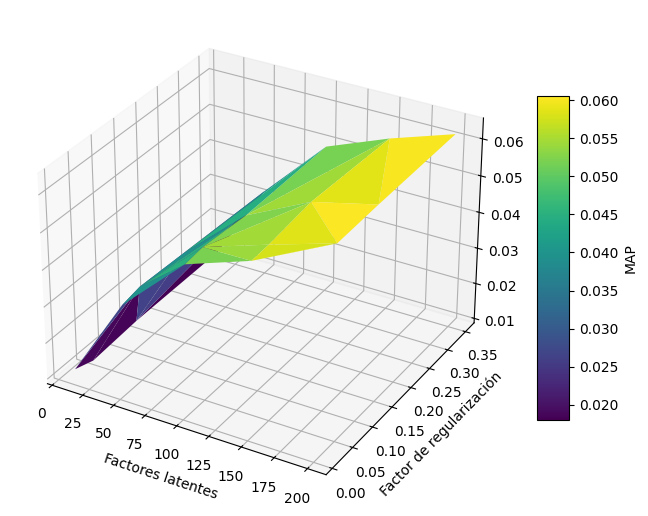

In [45]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 7))
# Gráfico para evolución del MAP de acuerdo a cambios en los factores latentes y factor de regularizaci[ón]
surf = ax.plot_trisurf([p[0] for p in als_perf.keys()], [p[1] for p in als_perf.keys()], [m.map for m in als_perf.values()], cmap="viridis")
fig.colorbar(surf, shrink=0.6, aspect=10, label="MAP")
ax.set_xlabel("Factores latentes")
ax.set_ylabel("Factor de regularización")
plt.show()

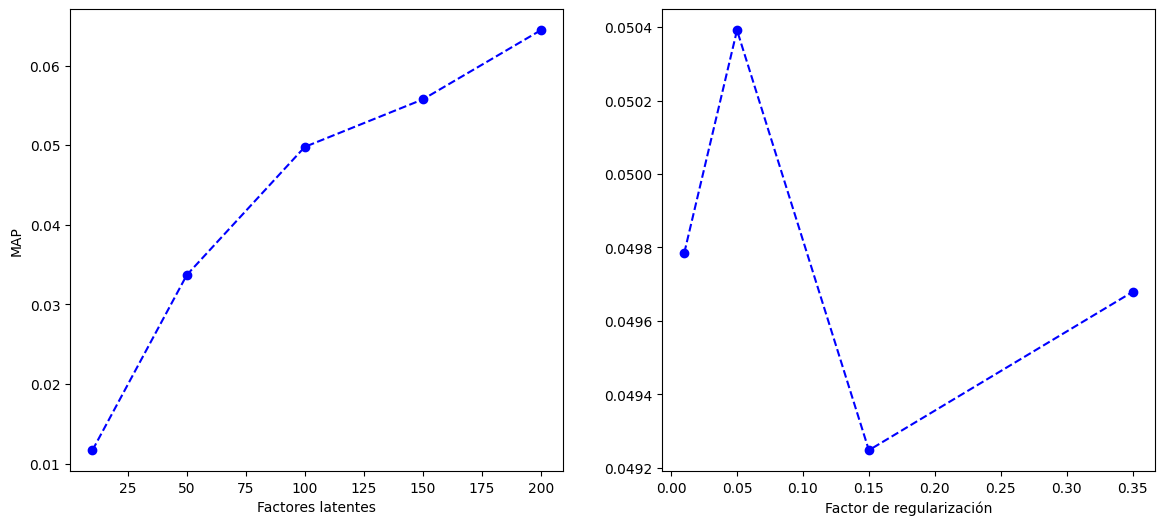

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos el MAP a partir de la cantidad de factores latentes con factor de regularización fijo en 0.01
axes[0].plot([key[0] for key in als_perf.keys() if key[1] == 0.01], [als_perf[key].map for key in als_perf.keys() if key[1] == 0.01], "--bo")
axes[0].set_xlabel("Factores latentes")
axes[0].set_ylabel("MAP")
# Graficamos el MAP a partir del factor de regularización con 100 factores latentes
axes[1].plot([key[1] for key in als_perf.keys() if key[0] == 100], [als_perf[key].map for key in als_perf.keys() if key[0] == 100], "--bo")
axes[1].set_xlabel("Factor de regularización")
plt.show()

### BPR

In [47]:
# Learning rate
lrs = [0.01, 0.05, 0.25]

bpr_perf = {}
bpr_train_em = []
bpr_eval_em = []

# Entrenamos el modelo con optimización BPR para cada combinación de parametros
for factor, reg, lr in itertools.product(factors, regs, lrs):
    # Medimos las emisiones de carbon que ocurren tras entrenar el modelo para combinación de parametros
    train_tracker = EmissionsTracker()
    train_tracker.start()

    model_bpr = implicit.bpr.BayesianPersonalizedRanking(
        factors=factor,
        regularization=reg,
        learning_rate=lr,
        iterations=40,
        use_gpu=False,
    )
    model_bpr.fit(user_item_matrix)

    train_emissions = train_tracker.stop()
    bpr_train_em.append(train_emissions)

    # Evaluamos el modelo con k=10 y medimos las emisiones
    eval_tracker = EmissionsTracker()
    eval_tracker.start()

    mean_recall, mean_ap, mean_ndcg = evaluate_model(model_bpr, 10)
    
    eval_emissions = eval_tracker.stop()
    bpr_eval_em.append(eval_emissions)

    bpr_perf[(factor, reg, lr)] = Metrics(mean_recall, mean_ap, mean_ndcg)

[codecarbon WARNING @ 18:24:20] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:24:22] [setup] RAM Tracking...
[codecarbon INFO @ 18:24:22] [setup] CPU Tracking...
[codecarbon INFO @ 18:24:22] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:24:22] [setup] GPU Tracking...
[codecarbon INFO @ 18:24:22] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 18:24:22] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: Power Gadget
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 18:24:22] >>> Tracker's metadata:
[codecarbon INFO @ 18:24:22]   Platform system: Windows-10-10.0.19045-SP0
[codecarbon INFO @ 18:24:22]   Python version: 3.12.0
[codecarbon INFO @ 18:24:22]   CodeCarbon version: 3.2.6
[codecarbon INFO @ 18:24:22]   Available RAM : 31.810 GB
[codecarbon INFO @ 18:24:22]   CPU count: 16 thread(s) in 1 physical CPU(

  0%|          | 0/40 [00:00<?, ?it/s]

[codecarbon INFO @ 18:24:25] Energy consumed for RAM : 0.000002 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:24:27] Delta energy consumed for CPU with intel_power_gadget : 0.000004 kWh, power : 47.930875000000015 W
[codecarbon INFO @ 18:24:27] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 18:24:27] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:24:27] Energy consumed for all GPUs : 0.000005 kWh. Total GPU Power : 13.001928879709965 W
[codecarbon INFO @ 18:24:27] 0.000011 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:24:27] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:24:28] [setup] RAM Tracking...
[codecarbon INFO @ 18:24:28] [setup] CPU Tracking...
[codecarbon INFO @ 18:24:28] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:24:28] [setup] GPU Tracking...
[codecarbon INFO @ 18:24:28] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO 

  0%|          | 0/40 [00:00<?, ?it/s]

[codecarbon INFO @ 18:24:38] Energy consumed for RAM : 0.000001 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:24:39] Delta energy consumed for CPU with intel_power_gadget : 0.000003 kWh, power : 46.18425000000002 W
[codecarbon INFO @ 18:24:39] Energy consumed for All CPU : 0.000003 kWh
[codecarbon INFO @ 18:24:39] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:24:39] Energy consumed for all GPUs : 0.000005 kWh. Total GPU Power : 12.76039199248568 W
[codecarbon INFO @ 18:24:39] 0.000010 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:24:39] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:24:40] [setup] RAM Tracking...
[codecarbon INFO @ 18:24:40] [setup] CPU Tracking...
[codecarbon INFO @ 18:24:40] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:24:40] [setup] GPU Tracking...
[codecarbon INFO @ 18:24:40] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 

...

[codecarbon INFO @ 18:36:12] Energy consumed for RAM : 0.000004 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:36:13] Delta energy consumed for CPU with intel_power_gadget : 0.000009 kWh, power : 45.348 W
[codecarbon INFO @ 18:36:13] Energy consumed for All CPU : 0.000009 kWh
[codecarbon INFO @ 18:36:13] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:36:13] Energy consumed for all GPUs : 0.000008 kWh. Total GPU Power : 14.48276368724097 W
[codecarbon INFO @ 18:36:13] 0.000021 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:36:13] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:36:14] [setup] RAM Tracking...
[codecarbon INFO @ 18:36:14] [setup] CPU Tracking...
[codecarbon INFO @ 18:36:14] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:36:14] [setup] GPU Tracking...
[codecarbon INFO @ 18:36:14] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 18:36:14] T

  0%|          | 0/40 [00:00<?, ?it/s]

[codecarbon INFO @ 18:36:25] Energy consumed for RAM : 0.000004 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:36:26] Delta energy consumed for CPU with intel_power_gadget : 0.000008 kWh, power : 40.7395 W
[codecarbon INFO @ 18:36:26] Energy consumed for All CPU : 0.000008 kWh
[codecarbon INFO @ 18:36:26] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:36:26] Energy consumed for all GPUs : 0.000007 kWh. Total GPU Power : 12.723082791307203 W
[codecarbon INFO @ 18:36:26] 0.000018 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:36:26] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:36:27] [setup] RAM Tracking...
[codecarbon INFO @ 18:36:27] [setup] CPU Tracking...
[codecarbon INFO @ 18:36:27] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:36:27] [setup] GPU Tracking...
[codecarbon INFO @ 18:36:27] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 18:36:27]

  0%|          | 0/40 [00:00<?, ?it/s]

[codecarbon INFO @ 18:36:37] Energy consumed for RAM : 0.000003 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 18:36:38] Delta energy consumed for CPU with intel_power_gadget : 0.000006 kWh, power : 34.1025 W
[codecarbon INFO @ 18:36:38] Energy consumed for All CPU : 0.000006 kWh
[codecarbon INFO @ 18:36:38] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 18:36:38] Energy consumed for all GPUs : 0.000006 kWh. Total GPU Power : 12.109431301688836 W
[codecarbon INFO @ 18:36:38] 0.000016 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 18:36:38] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:36:40] [setup] RAM Tracking...
[codecarbon INFO @ 18:36:40] [setup] CPU Tracking...
[codecarbon INFO @ 18:36:40] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 18:36:40] [setup] GPU Tracking...
[codecarbon INFO @ 18:36:40] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 18:36:40]

In [48]:
print(f"Emisiones promedio durante el entrenamiento del modelo BPR: {np.mean(bpr_train_em)}")
print(f"Emisiones promedio durante la evaluación del modelo BPR: {np.mean(bpr_eval_em)}")

Emisiones promedio durante el entrenamiento del modelo BPR: 4.1098488927850716e-06
Emisiones promedio durante la evaluación del modelo BPR: 3.6496798445464228e-06


In [78]:
# Mejor combinación de parametros segun MAP
sorted(bpr_perf.items(), key=lambda item: item[1].map, reverse=True)[0]

((100, 0.01, 0.25),
 Metrics(mrecall=nan, map=0.04174977587934401, ndcg=0.05808509600446783))

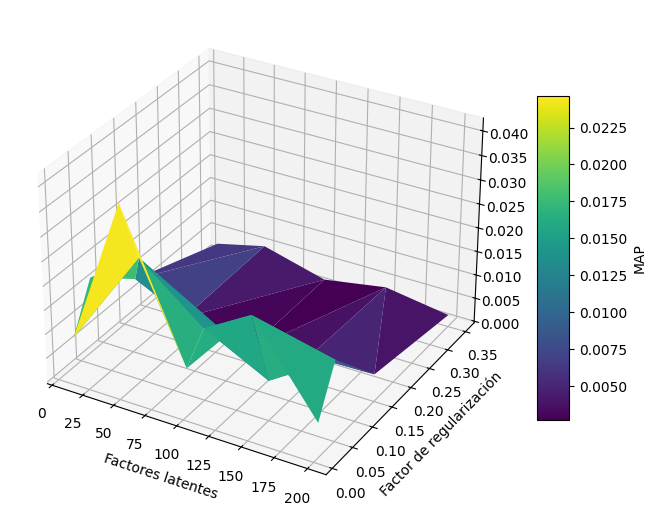

In [51]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 7))
# Gráfico para evolución del MAP de acuerdo a cambios en los factores latentes y factor de regularizaci[ón]
surf = ax.plot_trisurf([p[0] for p in bpr_perf.keys()], [p[1] for p in bpr_perf.keys()], [m.map for m in bpr_perf.values()], cmap="viridis")
fig.colorbar(surf, shrink=0.6, aspect=10, label="MAP")
ax.set_xlabel("Factores latentes")
ax.set_ylabel("Factor de regularización")
plt.show()

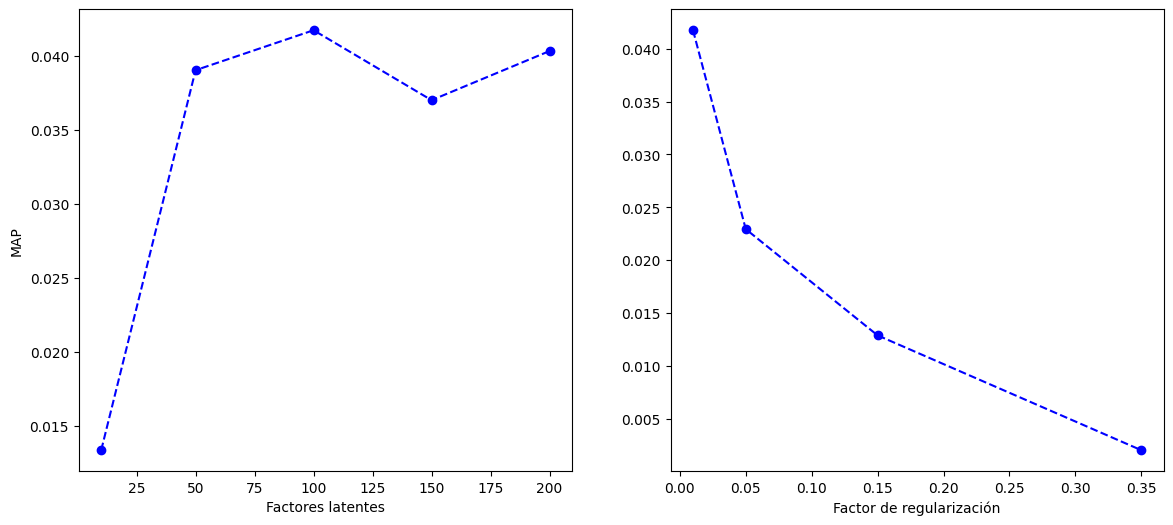

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos el MAP a partir de la cantidad de factores latentes con factor de regularización fijo en 0.01
axes[0].plot(
    [key[0] for key in bpr_perf.keys() if (key[1] == 0.01 and key[2] == 0.25)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[1] == 0.01 and key[2] == 0.25)
    ],
    "--bo",
)
axes[0].set_xlabel("Factores latentes")
axes[0].set_ylabel("MAP")
# Graficamos el MAP a partir del factor de regularización con 100 factores latentes
axes[1].plot(
    [key[1] for key in bpr_perf.keys() if (key[0] == 100 and key[2] == 0.25)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[0] == 100 and key[2] == 0.25)
    ],
    "--bo",
)
axes[1].set_xlabel("Factor de regularización")
plt.show()

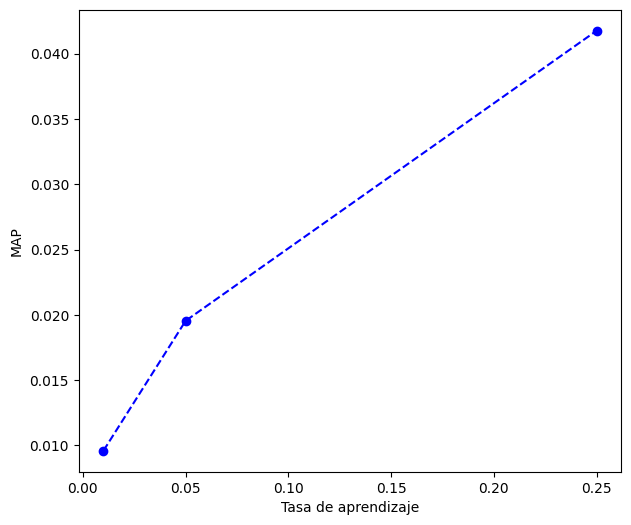

In [62]:
# Graficamos el MAP a partir del learning rate, con una cantidad fija de factores latentes y factor de regularización
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    [key[2] for key in bpr_perf.keys() if (key[1] == 0.01 and key[0] == 100)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[1] == 0.01 and key[0] == 100)
    ],
    "--bo",
)

ax.set_xlabel("Tasa de aprendizaje")
ax.set_ylabel("MAP")

plt.show()

### Content-based

In [ ]:
# Embeddings de imágenes
wk_emb = np.load("wikimedia_image_embeddings.npy")
# Mapeo de id de la imágen a indice en el array de embeddings
wk_id2idx = np.load("wikimedia_item_id_to_idx.npy", allow_pickle=True).item()
# Mapeo de indice del embedding de la imágen, a su id
wk_idx2id = {value: key for key, value in wk_id2idx.items()}

In [ ]:
# Función para generar recomendaciones para usuarios. Basada en código de práctico 4
def content_recommend(embedding, user_id=None, topk=10, metric='cosine'):
    #user_id = str(user_id)

    trx = user_items[user_id]
    n = embedding.shape[0]
    distances = 1e9

    # Recorremos imagenes del set de entrenamiento que calificó el usuario
    for t in trx:
        query_i = wk_id2idx[t]

        # Recomendamos items más cercanos a items con los que interactuó el usuario
        distances = np.minimum(distances, pairwise_distances(
                embedding[query_i].reshape(1,-1), embedding, metric=metric).reshape(-1))

    # Rank items de menor a mayor distancia (nos quedamos con los top-k)
    trx_set = set(trx)
    heap = []
    for i in range(n):
        if wk_idx2id[i] in trx_set:
            continue
        if len(heap) < topk:
            heapq.heappush(heap, (-distances[i], i))
        else:
            heapq.heappushpop(heap, (-distances[i], i))
    heap.sort(reverse=True)

    # Utilizamos un heap para extraer los items ordenados de menor a mayor distancia
    recommended_ids = [wk_idx2id[i] for _,i in heap]

    # Retornar los que el usuario no haya consumido
    filtered_recommended_ids = []

    return recommended_ids

In [ ]:
# Evaluamos el recomendador utilizando los embeddings de ResNet
top_k = 10
cb_mean_ap = 0
cb_mean_ndcg = 0

eval_tracker = EmissionsTracker()
eval_tracker.start()

for user_id in user_items_val.keys():
    user_row = user2row[user_id]
    rec = content_recommend(wk_emb, user_id, top_k, "cosine")
    rel_vector = np.isin(rec, user_items_val[user_id], assume_unique=True).astype(int)
    mean_recall += np.nan_to_num(recall_at_k(rel_vector, top_k))
    mean_ap += average_precision_at_k(rel_vector, top_k)
    mean_ndcg += ndcg_at_k(rel_vector, top_k)

cb_eval_em = eval_tracker.stop()

mean_recall /= len(user_items_val)
mean_ap /= len(user_items_val)
mean_ndcg /= len(user_items_val)

[codecarbon WARNING @ 17:53:50] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:53:52] [setup] RAM Tracking...
[codecarbon INFO @ 17:53:52] [setup] CPU Tracking...
[codecarbon INFO @ 17:53:52] Tracking Intel CPU via Power Gadget
[codecarbon INFO @ 17:53:52] [setup] GPU Tracking...
[codecarbon INFO @ 17:53:52] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 17:53:52] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: Power Gadget
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 17:53:52] >>> Tracker's metadata:
[codecarbon INFO @ 17:53:52]   Platform system: Windows-10-10.0.19045-SP0
[codecarbon INFO @ 17:53:52]   Python version: 3.12.0
[codecarbon INFO @ 17:53:52]   CodeCarbon version: 3.2.6
[codecarbon INFO @ 17:53:52]   Available RAM : 31.810 GB
[codecarbon INFO @ 17:53:52]   CPU count: 16 thread(s) in 1 physical CPU(

In [ ]:
print(f"Emisiones durante la evaluación del recomendador basado en contenido: {cb_eval_em}")

Emisiones durante la evaluación del recomendador basado en contenido: 0.006333288304976322


In [ ]:
print(f"Mean Recall@10: {mean_recall}")
print(f"MAP: {mean_ap}")
print(f"ndcg@10: {mean_ndcg}")

Mean Recall@10: nan
MAP: 0.03171098646200863
ndcg@10: 0.036201991181703835
